Buscando Canal 13 (ABI) para el 2026-04-16 18:00:00 UTC...
Imagen ABI cargada exitosamente.
Buscando descargas eléctricas GLM (últimos 30 min)...
Total de destellos (flashes) identificados: 448
Logos ajustados correctamente.
¡Imagen generada con éxito y caja compacta!: /Users/diegoperales/Meteorology/GOES/procesados/GOES19_IR_GLM_SENAMHI_Perfect_20260416_1805.png


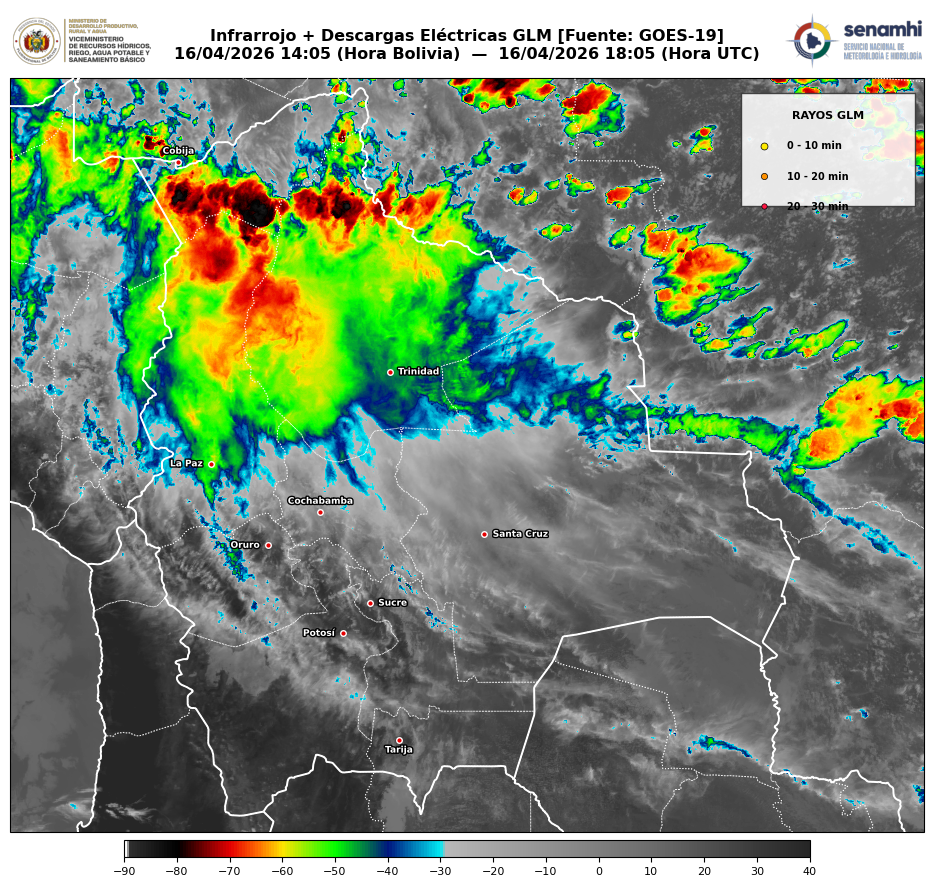

In [3]:
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as patheffects
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import s3fs

# ==========================================
# 1. CONFIGURACIÓN DEL USUARIO Y TIEMPO
# ==========================================
FECHA_BUSCADA = datetime(2026, 4, 16, 18, 00)  # Fecha/Hora de la escena (UTC)
MINUTOS_ACUMULACION_GLM = 30  # Ventana de acumulación de rayos

BASE_DIR = "/Users/diegoperales/Meteorology/GOES"
RAW_DATA = os.path.join(BASE_DIR, "raw_data")
OUTPUTS = os.path.join(BASE_DIR, "procesados")
os.makedirs(RAW_DATA, exist_ok=True)
os.makedirs(OUTPUTS, exist_ok=True)

# Conexión S3 de la NOAA
fs = s3fs.S3FileSystem(anon=True)
doy = FECHA_BUSCADA.strftime('%j')
anio = FECHA_BUSCADA.strftime('%Y')
hora = FECHA_BUSCADA.strftime('%H')

# ==========================================
# 2. DESCARGA DEL CANAL 13 (ABI INFRARROJO)
# ==========================================
print(f"Buscando Canal 13 (ABI) para el {FECHA_BUSCADA} UTC...")
s3_folder_abi = f"noaa-goes19/ABI-L2-CMIPF/{anio}/{doy}/{hora}/"

try:
    archivos_abi = fs.ls(s3_folder_abi)
    archivos_b13 = [f for f in archivos_abi if "M6C13" in f or "M3C13" in f]
    if not archivos_b13:
        raise FileNotFoundError("No se encontró el archivo del Canal 13.")
    
    s3_path_abi = archivos_b13[0]
    file_name_abi = s3_path_abi.split('/')[-1]
    local_path_abi = os.path.join(RAW_DATA, file_name_abi)
    
    if not os.path.exists(local_path_abi):
        fs.get(s3_path_abi, local_path_abi)
    
    ds_abi = xr.open_dataset(local_path_abi)
    print("Imagen ABI cargada exitosamente.")
except Exception as e:
    print(f"Error cargando ABI: {e}")
    raise e

# ==========================================
# 3. DESCARGA DE DATOS GLM (RAYOS)
# ==========================================
print(f"Buscando descargas eléctricas GLM (últimos {MINUTOS_ACUMULACION_GLM} min)...")
s3_folder_glm = f"noaa-goes19/GLM-L2-LCFA/{anio}/{doy}/{hora}/"

lats_glm, lons_glm, tiempos_glm = [], [], []

try:
    archivos_glm = fs.ls(s3_folder_glm)
    for filepath in archivos_glm:
        fname = filepath.split('/')[-1]
        time_str = fname.split('_s')[1][:11] # YYYYJJJHHMM
        f_dt = datetime.strptime(time_str, '%Y%j%H%M')
        
        if (FECHA_BUSCADA - timedelta(minutes=MINUTOS_ACUMULACION_GLM)) <= f_dt <= FECHA_BUSCADA:
            local_path_glm = os.path.join(RAW_DATA, fname)
            if not os.path.exists(local_path_glm):
                fs.get(filepath, local_path_glm)
            
            ds_glm = xr.open_dataset(local_path_glm)
            if 'flash_lat' in ds_glm and ds_glm.flash_lat.size > 0:
                lats_glm.extend(ds_glm.flash_lat.values.tolist())
                lons_glm.extend(ds_glm.flash_lon.values.tolist())
                tiempos_glm.extend(ds_glm.flash_time_offset_of_first_event.values.tolist())
            ds_glm.close()

    print(f"Total de destellos (flashes) identificados: {len(lats_glm)}")
except Exception as e:
    print(f"Aviso sobre GLM: No se pudieron procesar descargas eléctricas ({e}).")

# ==========================================
# 4. EXTRACCIÓN DE PARÁMETROS Y PALETA CIRA
# ==========================================
glob_attrs = ds_abi.goes_imager_projection.attrs
height = glob_attrs['perspective_point_height']
lon_0 = glob_attrs['longitude_of_projection_origin']
sweep = glob_attrs['sweep_angle_axis']

dataprojenv = ccrs.Geostationary(central_longitude=lon_0, satellite_height=height, sweep_axis=sweep)
temp_celsius = ds_abi.CMI - 273.15

VMIN, VMAX = -90, 40
rango_total = VMAX - VMIN
def pos(temp): return (temp - VMIN) / rango_total

colors_cira_exact = [
    (pos(-90), '#ffffff'), (pos(-89), '#2E2E2E'), (pos(-80), '#000000'),
    (pos(-70), '#E50001'), (pos(-65), '#FE6602'), (pos(-60), '#FEE500'),
    (pos(-50), '#02FE00'), (pos(-40), '#00157F'), (pos(-30), '#01EAF3'),
    (pos(-29), '#B8B8B8'), (pos(0),  '#7E7E7E'), (pos(10), '#6C6C6C'),
    (pos(20),  '#525252'), (pos(30), '#3A3A3A'), (pos(40), '#262626')
]
cmap_cira_perfecto = LinearSegmentedColormap.from_list('cira_rammb_exact', colors_cira_exact)

# ==========================================
# 5. GENERACIÓN DEL PRODUCTO VISUAL (CÓDIGO MADRE)
# ==========================================
fig, ax = plt.subplots(figsize=(10, 9.5), facecolor='white', subplot_kw={'projection': ccrs.PlateCarree()})

# Optimizamos los subplots tal cual tu código madre
fig.subplots_adjust(left=0.01, right=0.99, top=0.88, bottom=0.06)

# --- AJUSTE GEOGRÁFICO EQUILIBRADO ---
ax.set_extent([-71.8, -55.2, -23.2, -9.5], crs=ccrs.PlateCarree())

# --- CAPA 1: IMAGEN SATELITAL ---
im = ax.pcolormesh(ds_abi.x * height, ds_abi.y * height, temp_celsius, 
                   transform=dataprojenv, cmap=cmap_cira_perfecto, vmin=VMIN, vmax=VMAX)

# --- CAPA 2: LÍMITES GEOGRÁFICOS ---
COLOR_BLANCO = '#ffffff'
ax.add_feature(cfeature.COASTLINE, linestyle='-', edgecolor=COLOR_BLANCO, linewidth=1.4, zorder=3)
ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor=COLOR_BLANCO, linewidth=1.4, zorder=3)
ax.add_feature(cfeature.STATES, linestyle=(0, (1, 2)), edgecolor=COLOR_BLANCO, linewidth=0.7, zorder=4)

# --- CAPA 3: DESCARGAS ELÉCTRICAS GLM (CORREGIDO CORRECCIÓN DE TIPO) ---
if len(lats_glm) > 0:
    lats_glm = np.array(lats_glm, dtype=np.float64)
    lons_glm = np.array(lons_glm, dtype=np.float64)
    tiempos_glm = pd.to_datetime(tiempos_glm)
    
    diferencia_min = (FECHA_BUSCADA - tiempos_glm).total_seconds() / 60.0
    
    m_rojo = (diferencia_min > 20) & (diferencia_min <= 30)
    m_naranja = (diferencia_min > 10) & (diferencia_min <= 20)
    m_amarillo = (diferencia_min >= 0) & (diferencia_min <= 10)
    
    # Dibujar con zorder alto (20) para que salgan SIEMPRE al frente
    # 20-30 min (Rojo)
    ax.scatter(lons_glm[m_rojo], lats_glm[m_rojo], color='#FF1744', s=18, marker='o', 
               edgecolors='black', linewidths=0.4, zorder=20, transform=ccrs.PlateCarree())
    # 10-20 min (Naranja)
    ax.scatter(lons_glm[m_naranja], lats_glm[m_naranja], color='#FF9100', s=24, marker='o', 
               edgecolors='black', linewidths=0.5, zorder=21, transform=ccrs.PlateCarree())
    # 0-10 min (Amarillo Neón)
    ax.scatter(lons_glm[m_amarillo], lats_glm[m_amarillo], color='#FFEA00', s=32, marker='o', 
               edgecolors='black', linewidths=0.6, zorder=22, transform=ccrs.PlateCarree())

# --- CAPA 4: CAPITALES DE DEPARTAMENTO ---
capitales = {
    "Cobija":        {"lat": -11.02, "lon": -68.74, "pos": "top"},
    "Trinidad":      {"lat": -14.83, "lon": -64.90, "pos": "right"},
    "La Paz":        {"lat": -16.50, "lon": -68.15, "pos": "left"},
    "Cochabamba":    {"lat": -17.38, "lon": -66.16, "pos": "top"},
    "Santa Cruz":    {"lat": -17.78, "lon": -63.18, "pos": "right"},
    "Oruro":         {"lat": -17.98, "lon": -67.11, "pos": "left"},
    "Sucre":         {"lat": -19.03, "lon": -65.26, "pos": "right"},
    "Potosí":        {"lat": -19.58, "lon": -65.75, "pos": "left"},
    "Tarija":        {"lat": -21.53, "lon": -64.73, "pos": "bottom"}
}

for ciudad, info in capitales.items():
    ax.plot(info["lon"], info["lat"], marker='o', color='#E50001', 
            markersize=4, markeredgecolor='white', markeredgewidth=1.0, 
            transform=ccrs.PlateCarree(), zorder=25)
    
    offset_lon = 0.15 if info["pos"] == "right" else (-0.15 if info["pos"] == "left" else 0)
    offset_lat = 0.15 if info["pos"] == "top" else (-0.22 if info["pos"] == "bottom" else -0.05)
    alignment_h = "left" if info["pos"] == "right" else ("right" if info["pos"] == "left" else "center")
    
    ax.text(info["lon"] + offset_lon, info["lat"] + offset_lat, ciudad,
            color='white', fontsize=6.5, fontweight='bold',
            horizontalalignment=alignment_h, transform=ccrs.PlateCarree(), zorder=26,
            path_effects=[patheffects.withStroke(linewidth=2, foreground='black')])

# --- CAPA 5: TÍTULO ---
fecha_utc = datetime.strptime(ds_abi.t.dt.strftime('%Y-%m-%d %H:%M').item(), '%Y-%m-%d %H:%M')
fecha_bot = fecha_utc - timedelta(hours=4)

string_utc = fecha_utc.strftime('%d/%m/%Y %H:%M (Hora UTC)')
string_bot = fecha_bot.strftime('%d/%m/%Y %H:%M (Hora Bolivia)')

ax.set_title(f"Infrarrojo + Descargas Eléctricas GLM [Fuente: GOES-19]\n{string_bot}  —  {string_utc}", 
             fontsize=11.5, fontweight='bold', pad=14, loc='center', linespacing=1.3)

# --- CAPA 6: BARRA DE COLORES ORIGINAL (100% ANCHO) ---
cbar = fig.colorbar(
    im, 
    orientation='horizontal', 
    pad=0.01,          
    shrink=1.0,        
    fraction=0.022,    
    aspect=40,         
    ax=ax              
)

valores_ticks = [-90, -80, -70, -60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40]
cbar.set_ticks(valores_ticks)
cbar.ax.tick_params(labelsize=8)

pos_cbar = cbar.ax.get_position()
cbar.ax.set_axes_locator(None) 
cbar.ax.set_position([
    0.00,              # Extremo izquierdo absoluto (0%)
    pos_cbar.y0,       # Conserva la altura vertical
    1.00,              # Extremo derecho absoluto (100%)
    pos_cbar.height    # Grosor estilizado
])

# --- CAPA 7: RECUADRO FLOTANTE DE LEYENDA GLM (INSET INTEGRADO) ---
# Usamos un parche de fondo dibujado sobre el propio lienzo del mapa
# [x_inicio, y_inicio, ancho, alto] en coordenadas del mapa (0 a 1)
rect = plt.Rectangle((0.80, 0.83), 0.19, 0.15, transform=ax.transAxes,
                     facecolor='white', alpha=0.88, edgecolor='#333333', linewidth=1, zorder=30)
ax.add_patch(rect)

# Textos y Símbolos dentro del recuadro
ax.text(0.895, 0.95, "RAYOS GLM", transform=ax.transAxes, 
        ha='center', va='center', fontsize=8, fontweight='bold', zorder=31)

# 0 - 10 min (Amarillo)
ax.scatter(0.825, 0.91, color='#FFEA00', s=25, edgecolors='black', linewidths=0.5, 
           transform=ax.transAxes, zorder=31)
ax.text(0.85, 0.91, "0 - 10 min", transform=ax.transAxes, 
        va='center', fontsize=7, fontweight='bold', zorder=31)

# 10 - 20 min (Naranja)
ax.scatter(0.825, 0.87, color='#FF9100', s=20, edgecolors='black', linewidths=0.5, 
           transform=ax.transAxes, zorder=31)
ax.text(0.85, 0.87, "10 - 20 min", transform=ax.transAxes, 
        va='center', fontsize=7, fontweight='bold', zorder=31)

# 20 - 30 min (Rojo)
ax.scatter(0.825, 0.83, color='#FF1744', s=15, edgecolors='black', linewidths=0.5, 
           transform=ax.transAxes, zorder=31)
ax.text(0.85, 0.83, "20 - 30 min", transform=ax.transAxes, 
        va='center', fontsize=7, fontweight='bold', zorder=31)

# --- CAPA 8: LOGOS ---
PATH_LOGOS = os.path.join(BASE_DIR, "logos")
try:
    img_ministerio_path = os.path.join(PATH_LOGOS, "logo_ministerio.png")
    img_senamhi_path = os.path.join(PATH_LOGOS, "logo_senamhi.png")
    
    if os.path.exists(img_ministerio_path) and os.path.exists(img_senamhi_path):
        logo_ministerio = mpimg.imread(img_ministerio_path)
        logo_senamhi = mpimg.imread(img_senamhi_path)
        
        pos_mapa = ax.get_position()
        
        ax_logo_min = fig.add_axes([pos_mapa.x0, pos_mapa.y1 + 0.005, 0.14, 0.07]) 
        ax_logo_min.imshow(logo_ministerio)
        ax_logo_min.axis('off')
        
        ax_logo_sen = fig.add_axes([pos_mapa.x1 - 0.14, pos_mapa.y1 + 0.005, 0.14, 0.07]) 
        ax_logo_sen.imshow(logo_senamhi)
        ax_logo_sen.axis('off')
        print("Logos ajustados correctamente.")
except Exception as e:
    print(f"Alerta con logos: {e}")

# Guardado con recorte ajustado al mapa exacto
output_name = f"{OUTPUTS}/GOES19_IR_GLM_SENAMHI_Perfect_{fecha_utc.strftime('%Y%m%d_%H%M')}.png"
plt.savefig(output_name, dpi=200, bbox_inches='tight', pad_inches=0.03)
print(f"¡Imagen generada con éxito y caja compacta!: {output_name}")

plt.show()